### Imports and Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
import os
os.chdir(r"C:\Users\hites\job-market-analytics")
print("Working directory:", os.getcwd())

# Style
plt.rcParams["figure.figsize"]=(12, 5)
sns.set_theme(style="darkgrid")

# Load Data
df=pd.read_csv(r"data\cleaned_jobs.csv")
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Working directory: C:\Users\hites\job-market-analytics
Dataset Shape: (371, 16)

Columns: ['title', 'company', 'location', 'category', 'salary_min', 'salary_max', 'contract_type', 'description', 'search_term', 'city', 'salary_avg', 'has_salary', 'post_date', 'post_month', 'work_type', 'skills_found']


,title,company,location,category,salary_min,salary_max,contract_type,description,search_term,city,salary_avg,has_salary,post_date,post_month,work_type,skills_found
0,Graduate Finance Data Analyst,Hays,"Manchester, Greater Manchester",Graduate Jobs,31607.44,31607.44,Unknown,Graduate Finance Data Analyst - Manchester - I...,data analyst,Manchester,31607.44,1,2026-06-05,2026-06,On-site,"excel, r"
1,Data Analyst Trainee,ITOL Recruit,UK,IT Jobs,30000.00,50000.00,permanent,Are you looking to benefit from a new career i...,data analyst,UK,40000.00,1,2026-06-01,2026-06,On-site,r
2,Data Analyst,Dale Farm Ltd,"Belfast, Northern Ireland",IT Jobs,35000.00,35000.00,Unknown,About the Role Document and develop an underst...,data analyst,Belfast,35000.00,1,2026-06-11,2026-06,On-site,r
3,Data Analyst,Robert Half,"Gloucestershire, South West England",IT Jobs,42022.07,42022.07,contract,Contract Data Analyst Role: Data Analyst Rate:...,data analyst,Gloucestershire,42022.07,1,2026-06-05,2026-06,Hybrid,r
4,Data Analyst,Advanced Resource Managers Limited,"Gloucestershire, South West England",IT Jobs,104000.00,104000.00,contract,Data Analyst Contract up to 31/12/2026 Based i...,data analyst,Gloucestershire,104000.00,1,2026-05-19,2026-05,On-site,r


In [7]:
print("BASIC STATISTICS")
print(f"Total jobs: {len(df)}")
print(f"Unique Companies: {df['company'].nunique()}")
print(f"Unique Cities: {df['city'].nunique()}")
print(f"Date Range: {df['post_date'].min()} to {df['post_date'].max()}")
print(f"\nWork type breakdown:")
print(df['work_type'].value_counts())
print(f"\nTop 5 job categories:")
print(df['category'].value_counts().head())

BASIC STATISTICS
Total jobs: 371
Unique Companies: 183
Unique Cities: 120
Date Range: 2025-01-16 to 2026-06-12

Work type breakdown:
work_type
On-site    245
Hybrid      95
Remote      31
Name: count, dtype: int64

Top 5 job categories:
category
IT Jobs                      351
Engineering Jobs              12
Accounting & Finance Jobs      3
Graduate Jobs                  2
Healthcare & Nursing Jobs      1
Name: count, dtype: int64


### Top Cities Chart

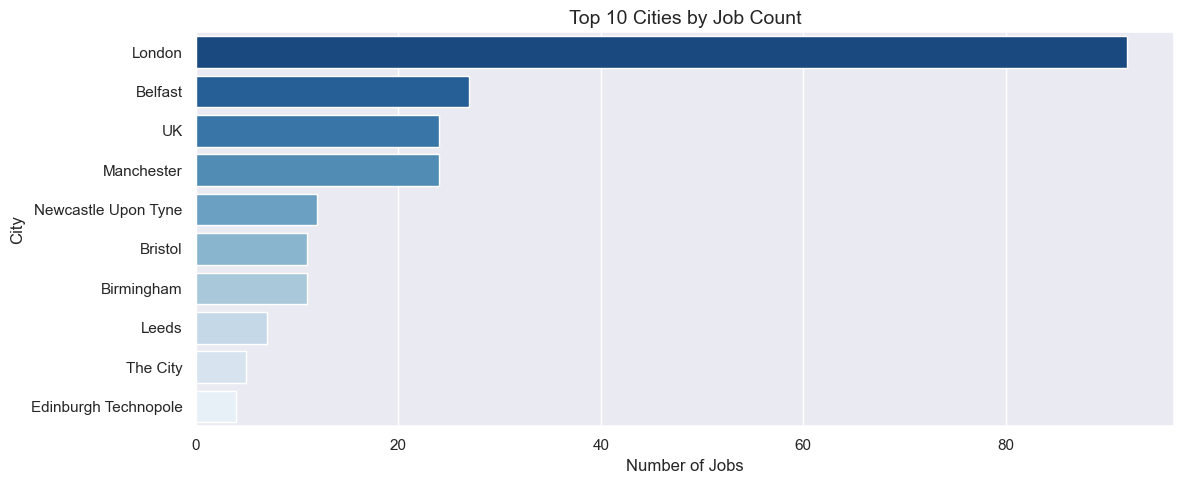

In [8]:
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Blues_r")
plt.title("Top 10 Cities by Job Count", fontsize=14)
plt.xlabel("Number of Jobs")
plt.ylabel("City")
plt.tight_layout()
plt.savefig("data/chart_top_cities.png")
plt.show()

### Work type pie chart

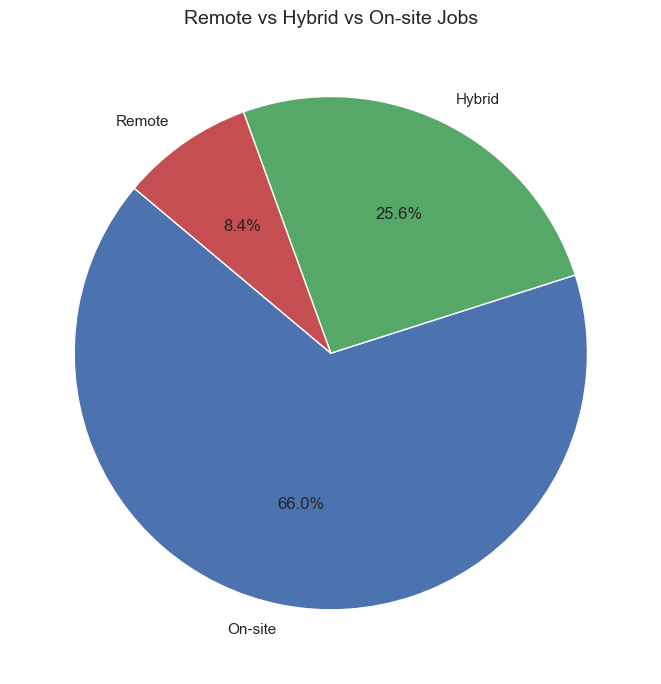

In [9]:
work_counts=df['work_type'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(work_counts.values,
        labels=work_counts.index,
        autopct="%1.1f%%",
        colors=["#4C72B0","#55A868","#C44E52"],
        startangle=140)
plt.title("Remote vs Hybrid vs On-site Jobs", fontsize=14)
plt.tight_layout()
plt.savefig("data/chart_work_type.png")
plt.show()

### Salary analysis

Jobs with salary data: 371

Salary stats (£):
count       371.00
mean      64450.36
std       30292.39
min          25.00
25%       42388.76
50%       57574.03
75%       75000.00
max      221000.00
Name: salary_avg, dtype: float64


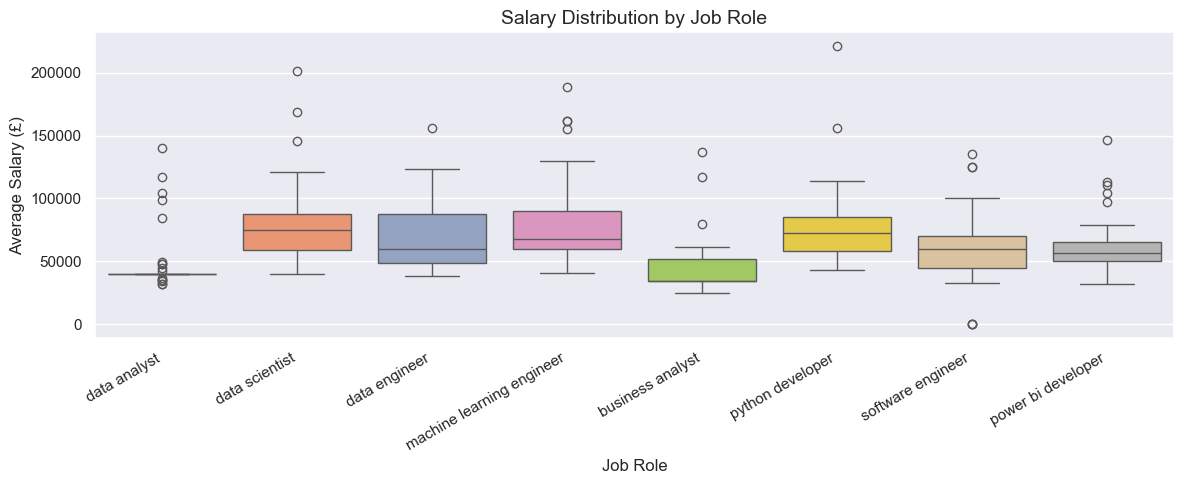

In [10]:
salary_df=df[df['salary_avg'] > 0].copy()

print(f"Jobs with salary data: {len(salary_df)}")
print(f"\nSalary stats (£):")
print(salary_df['salary_avg'].describe().round(2))

plt.figure(figsize=(12,5))
sns.boxplot(data=salary_df, x='search_term', y='salary_avg', palette="Set2")
plt.title("Salary Distribution by Job Role", fontsize=14)
plt.xlabel("Job Role")
plt.ylabel("Average Salary (£)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("data/chart_salary_by_role.png")
plt.show()

### Top skills analysis

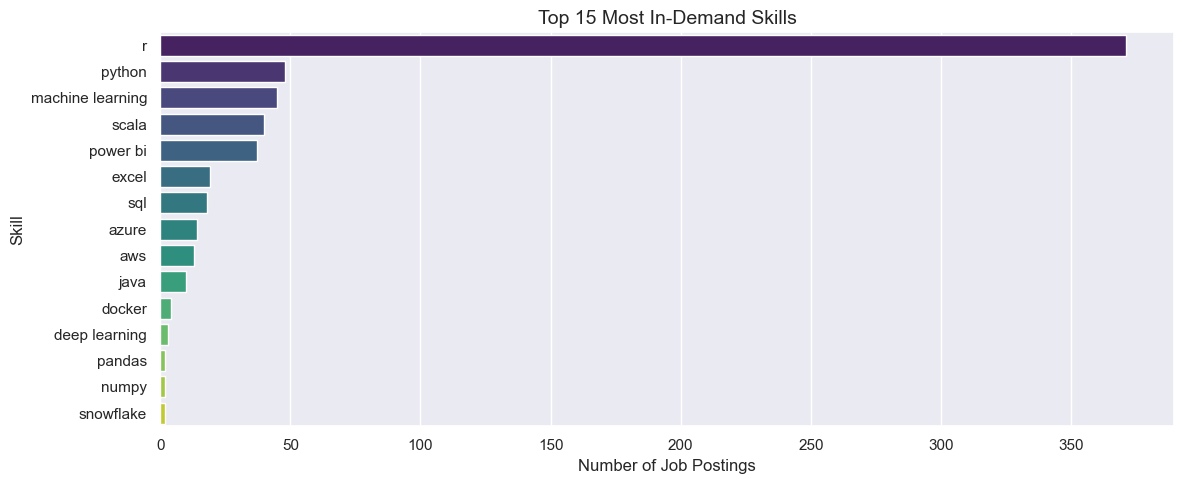

               skill  count
0                  r    371
1             python     48
2   machine learning     45
3              scala     40
4           power bi     37
5              excel     19
6                sql     18
7              azure     14
8                aws     13
9               java     10
10            docker      4
11     deep learning      3
12            pandas      2
13             numpy      2
14         snowflake      2


In [11]:
all_skills=[]
for skills in df['skills_found'].dropna():
    if skills:
        all_skills.extend([s.strip() for s in skills.split(",")])

skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(15),
                           columns=['skill', 'count'])

plt.figure(figsize=(12,5))
sns.barplot(data=top_skills, x='count', y='skill', palette="viridis")
plt.title("Top 15 Most In-Demand Skills", fontsize=14)
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("data/chart_top_skills.png")
plt.show()

print(top_skills)

### Jobs by search term

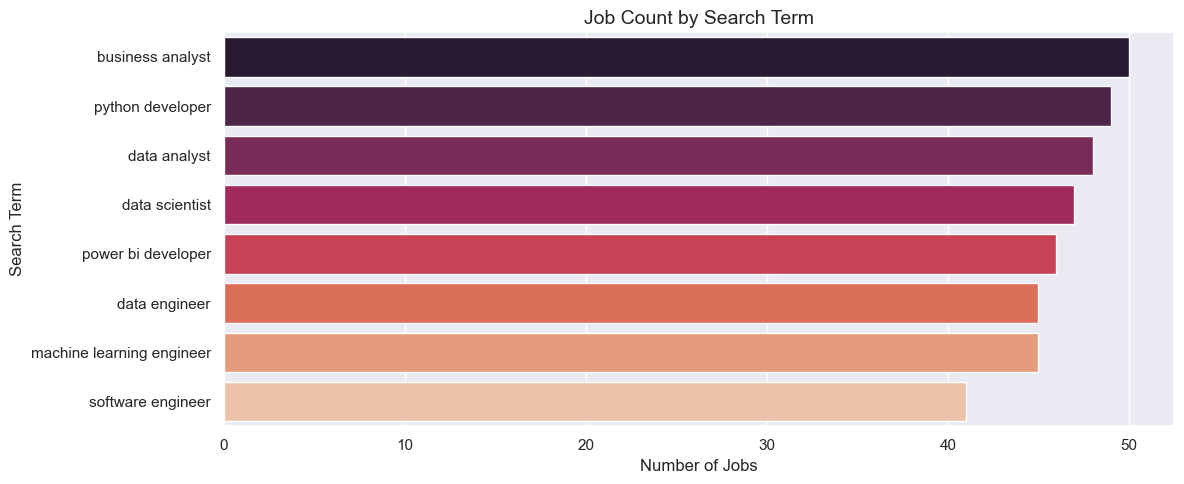

In [12]:
term_counts = df['search_term'].value_counts()

plt.figure(figsize=(12,5))
sns.barplot(x=term_counts.values, y=term_counts.index, palette="rocket")
plt.title("Job Count by Search Term", fontsize=14)
plt.xlabel("Number of Jobs")
plt.ylabel("Search Term")
plt.tight_layout()
plt.savefig("data/chart_jobs_by_term.png")
plt.show()

### Save EDA summary

In [13]:
summary = {
    "total_jobs": len(df),
    "unique_companies": df['company'].nunique(),
    "unique_cities": df['city'].nunique(),
    "top_city": df['city'].value_counts().index[0],
    "top_skill": top_skills.iloc[0]['skill'],
    "avg_salary": round(salary_df['salary_avg'].mean(), 2),
    "remote_pct": round((df['work_type']=='Remote').sum()/len(df)*100, 1),
    "hybrid_pct": round((df['work_type']=='Hybrid').sum()/len(df)*100, 1),
    "onsite_pct": round((df['work_type']=='On-site').sum()/len(df)*100, 1),
}

print("=== EDA SUMMARY ===")
for k, v in summary.items():
    print(f"  {k}: {v}")

=== EDA SUMMARY ===
  total_jobs: 371
  unique_companies: 183
  unique_cities: 120
  top_city: London
  top_skill: r
  avg_salary: 64450.36
  remote_pct: 8.4
  hybrid_pct: 25.6
  onsite_pct: 66.0
